# When Do Flights Leave Late? Seattle & Portland Departures, 2014

**Team:** [Member 1] · [Member 2] · [Member 3] · [Member 4]

## Business question
Operations at Seattle (SEA) and Portland (PDX) must decide where to put spare crews, gates and schedule buffer. **Which departures are most likely to leave more than 15 minutes late, and how much does weather matter compared with the schedule?**

## Summary
- **One flight in seven (14.4%)** left more than 15 minutes late.
- **Time of day matters most:** afternoon departures are delayed 21% of the time, early-morning ones 7%.
- **Carrier matters:** Southwest is delayed 27% of the time, Alaska 10%.
- **Weather matters only at the extremes**, such as freezing temperatures or poor visibility.
- **Our model ranks flights by risk well but cannot predict exact delay minutes.**

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

## 1. The data
- **`Flight.csv`:** every 2014 departure from SEA and PDX (162,049 flights).
- **`weather.csv`:** hourly weather at each airport (17,426 hours).

We fix two Excel export problems on load: an extra header row in the weather file and nine empty columns in the flight file.

In [2]:
# Upload Flight.csv and weather.csv to Colab first (folder icon on the left)

df_flights = pd.read_csv('Flight.csv')

# weather.csv has an extra row of column numbers (1, 2, 3 ... 16) above the real header
# header=1 tells pandas the real column names are on the second row
df_weather = pd.read_csv('weather.csv', header=1)

print('Flights:', df_flights.shape)
print('Weather:', df_weather.shape)

Flights: (162049, 26)
Weather: (17426, 16)


In [3]:
df_flights.head()

,Key_Flight,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,...,minute,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,PDX-2014-1-1-0,2014,1,1,1.0,96.0,235.0,70.0,AS,N508AS,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SEA-2014-1-1-0,2014,1,1,4.0,-6.0,738.0,-23.0,US,N195UW,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PDX-2014-1-1-0,2014,1,1,8.0,13.0,548.0,-4.0,UA,N37422,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PDX-2014-1-1-0,2014,1,1,28.0,-2.0,800.0,-23.0,US,N547UW,...,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SEA-2014-1-1-0,2014,1,1,34.0,44.0,325.0,43.0,AS,N762AS,...,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_weather.head()

,Key_Weather,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date
0,PDX-2014-1-1-0,PDX,2014,1,1,0,44.96,41.00,85.90,290.0,3.45234,3.972884,0.0,1026.9,8.0,01-01-14 0:00
1,PDX-2014-1-1-1,PDX,2014,1,1,1,44.96,39.92,82.38,290.0,6.90468,7.945768,0.0,1027.3,9.0,01-01-14 1:00
2,PDX-2014-1-1-2,PDX,2014,1,1,2,44.06,39.92,85.25,330.0,5.75390,6.621473,0.0,1027.4,9.0,01-01-14 2:00
3,PDX-2014-1-1-3,PDX,2014,1,1,3,44.06,39.92,85.25,280.0,6.90468,7.945768,0.0,1027.6,9.0,01-01-14 3:00
4,PDX-2014-1-1-4,PDX,2014,1,1,4,42.98,41.00,92.65,290.0,5.75390,6.621473,0.0,NaN,7.0,01-01-14 4:00


In [5]:
# Flight.csv has 9 empty columns left over from Excel (Unnamed: 17 ... Unnamed: 25)
print(df_flights.isnull().sum())

Key_Flight          0
year                0
month               0
day                 0
dep_time          857
dep_delay         857
arr_time          988
arr_delay        1301
carrier             0
tailnum           248
flight              0
origin              0
dest                0
air_time         1301
distance            0
hour              857
minute            857
Unnamed: 17    162049
Unnamed: 18    162049
Unnamed: 19    162049
Unnamed: 20    162049
Unnamed: 21    162049
Unnamed: 22    162049
Unnamed: 23    162049
Unnamed: 24    162049
Unnamed: 25    162049
dtype: int64


In [6]:
# Drop columns where every value is missing
df_flights = df_flights.dropna(axis=1, how='all')

# 'date' in the weather file repeats year, month, day and hour, so we do not need it
df_weather = df_weather.drop(columns='date')

print('Flights:', df_flights.shape)
print('Weather:', df_weather.shape)

Flights: (162049, 17)
Weather: (17426, 15)


## 2. Combining the sources
Each flight is matched to the weather at its airport, in the same hour of the same day. The match uses the key we built in Excel (for example SEA-2014-1-1-0), the same key we used in our VLOOKUP.

We chose a **left join**, which keeps every flight even when no weather record exists. Flights are what we are explaining, so none should disappear.

In [7]:
# Is each weather hour listed only once? If not, the join would duplicate flights
print('Duplicate weather keys:', df_weather['Key_Weather'].duplicated().sum())

# How many hours of weather does each airport have? A full year is 365 x 24 = 8,760
print(df_weather.groupby('origin').size())

Duplicate weather keys: 0
origin
PDX    8712
SEA    8714
dtype: int64


In [8]:
# Left join: keep every flight, add weather where the key matches
# Key_Flight and Key_Weather = origin-year-month-day-hour, e.g. SEA-2014-1-1-0 (same key as our Excel VLOOKUP)
# We only bring across the weather measurements - origin, year, month, day and hour are already in the flight file

weather_cols = ['Key_Weather', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed',
                'wind_gust', 'precip', 'pressure', 'visib']

df = pd.merge(df_flights,
              df_weather[weather_cols],
              left_on='Key_Flight',
              right_on='Key_Weather',
              how='left')

print('Flights before join:', len(df_flights))
print('Rows after join:    ', len(df))

Flights before join: 162049
Rows after join:     162049


In [9]:
# What did the join cost us?
matched = df['Key_Weather'].notnull().sum()
not_matched = df['Key_Weather'].isnull().sum()

print('Matched:    ', matched, f'({matched / len(df):.1%})')
print('Not matched:', not_matched, f'({not_matched / len(df):.1%})')

# Weather hours that no flight used (e.g. overnight when there are no departures)
print('Weather hours with no flight:', len(df_weather) - df['Key_Weather'].nunique())

Matched:     160280 (98.9%)
Not matched: 1769 (1.1%)
Weather hours with no flight: 2980


**What the join cost:** 160,280 flights (98.9%) matched and **1,769 (1.1%) did not**. We also found 2,980 weather hours with no departures, mostly overnight.

### Do the unmatched flights have anything in common?

In [10]:
# Do the unmatched flights have anything in common?
unmatched = df[df['Key_Weather'].isnull()]

# 1. Cancelled flights have no departure time, so their key ends in "-NA"
cancelled = unmatched['dep_time'].isnull().sum()

# 2. Flights that left at exactly midnight are recorded as hour 24 - weather uses 0-23
hour_24 = (unmatched['hour'] == 24).sum()

# 3. The rest: flights in an hour that is missing from the weather file
missing_weather = not_matched - cancelled - hour_24

print('Cancelled flights:           ', cancelled)
print('Hour recorded as 24:         ', hour_24)
print('Hour missing in weather file:', missing_weather)

Cancelled flights:            857
Hour recorded as 24:          19
Hour missing in weather file: 893


In [11]:
# Which dates are missing weather?
missing = unmatched[unmatched['dep_time'].notnull() & (unmatched['hour'] != 24)]
missing_dates = missing.groupby(['month', 'day']).size().sort_values(ascending=False)
print(missing_dates.head(10))

# The weather file stops on 30 December
print('Last weather day:', df_weather[df_weather['month'] == 12]['day'].max())

month  day
12     31     389
7      20     139
       8      122
       9       70
2      19      46
6      9       41
       18      31
7      18      16
4      24      12
9      13      12
dtype: int64
Last weather day: 30


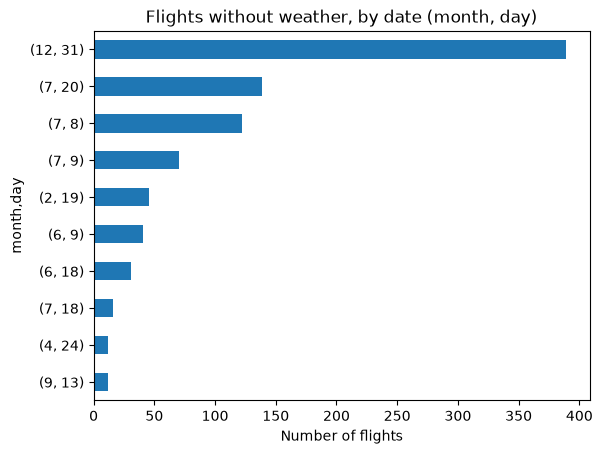

In [12]:
missing_dates.head(10).sort_values().plot(kind='barh')
plt.title('Flights without weather, by date (month, day)')
plt.xlabel('Number of flights')
plt.show()

Yes. The unmatched flights are not random. They fall into three groups:
- **857 cancelled flights**, which never departed and so have no hour to match on.
- **893 flights in hours missing from the weather file.** The weather file stops on 30 December, so all 389 New Year's Eve flights are missing weather.
- **19 flights recorded at "hour 24"** (midnight), which the weather file does not use.

The gaps sit on specific dates, not particular carriers or weather, so dropping them does not bias the findings. Python gives the same count as our Excel VLOOKUP.

In [13]:
# Does the Python join agree with the Excel VLOOKUP?
# Optional: only runs if the Excel file is also uploaded to Colab
import os
if os.path.exists('Flight_and_Weather_-_working.xlsx'):
    df_excel = pd.read_excel('Flight_and_Weather_-_working.xlsx')
    # the last column of the Excel sheet is the key returned by VLOOKUP (blank = no match)
    print('Excel VLOOKUP - flights without weather:', df_excel.iloc[:, -1].isnull().sum())
    print('Python join   - flights without weather:', not_matched)

## 3. What the data contains and its condition
The combined table covers 2 airports, 71 destinations, 11 carriers and all of 2014. It is mostly complete.

In [14]:
print('Rows and columns:', df.shape)
print('Airports:     ', list(df['origin'].unique()))
print('Carriers:     ', df['carrier'].nunique())
print('Destinations: ', df['dest'].nunique())
print('Year:         ', list(df['year'].unique()))

Rows and columns: (162049, 27)
Airports:      ['PDX', 'SEA']
Carriers:      11
Destinations:  71
Year:          [np.int64(2014)]


In [15]:
df.describe().round(1)

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,flight,air_time,distance,...,minute,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
count,162049.0,162049.0,162049.0,161192.0,161192.0,161061.0,160748.0,162049.0,160748.0,162049.0,...,161192.0,160247.0,160253.0,160247.0,156222.0,160208.0,160208.0,160280.0,134648.0,160274.0
mean,2014.0,6.6,15.7,1278.3,6.1,1482.5,2.2,1357.4,152.6,1204.5,...,30.3,54.1,45.3,74.5,156.5,7.1,8.1,0.0,1017.8,9.2
std,0.0,3.3,8.8,522.6,29.1,524.0,31.2,1495.3,72.5,653.2,...,18.1,11.4,22.3,17.0,110.0,5.0,5.7,0.0,6.6,2.3
min,2014.0,1.0,1.0,1.0,-37.0,1.0,-67.0,2.0,18.0,93.0,...,0.0,19.9,-2.9,12.3,0.0,0.0,0.0,0.0,986.4,0.0
25%,2014.0,4.0,8.0,831.0,-5.0,1127.0,-12.0,408.0,103.0,689.0,...,14.0,46.0,39.9,64.8,50.0,3.5,4.0,0.0,1014.0,10.0
50%,2014.0,7.0,16.0,1217.0,-2.0,1517.0,-4.0,694.0,129.0,991.0,...,30.0,54.0,46.9,79.4,170.0,6.9,7.9,0.0,1018.0,10.0
75%,2014.0,9.0,23.0,1721.0,5.0,1918.0,7.0,1726.0,199.0,1660.0,...,47.0,61.0,53.1,87.1,220.0,9.2,10.6,0.0,1021.4,10.0
max,2014.0,12.0,31.0,2400.0,1553.0,2400.0,1539.0,6527.0,422.0,2724.0,...,59.0,98.1,3282.8,100.0,360.0,38.0,43.7,0.3,1045.4,10.0


In [16]:
# Missing values in each column
df.isnull().sum()

Key_Flight         0
year               0
month              0
day                0
dep_time         857
dep_delay        857
arr_time         988
arr_delay       1301
carrier            0
tailnum          248
flight             0
origin             0
dest               0
air_time        1301
distance           0
hour             857
minute           857
Key_Weather     1769
temp            1802
dewp            1796
humid           1802
wind_dir        5827
wind_speed      1841
wind_gust       1841
precip          1769
pressure       27401
visib           1775
dtype: int64

### Things that look wrong

In [17]:
# Problem 1: dew point of 3,282 F is impossible (the maximum ever recorded on Earth is about 95 F)
print(df['dewp'].describe())
print('Rows with dew point above 100:', (df['dewp'] > 100).sum())

count    160253.000000
mean         45.341853
std          22.304347
min          -2.920000
25%          39.920000
50%          46.940000
75%          53.060000
max        3282.800000
Name: dewp, dtype: float64
Rows with dew point above 100: 6


In [18]:
# Problem 2: wind_gust is always exactly 1.15 x wind_speed, so it is not a real measurement
ratio = df_weather['wind_gust'] / df_weather['wind_speed']
print(ratio.describe())

count    1.514700e+04
mean     1.150780e+00
std      1.241382e-16
min      1.150780e+00
25%      1.150780e+00
50%      1.150780e+00
75%      1.150780e+00
max      1.150780e+00
dtype: float64


In [19]:
# Problem 3: pressure is missing for many flights
print('Share of flights missing pressure:', round(df['pressure'].isnull().mean() * 100, 1), '%')

Share of flights missing pressure: 16.9 %


In [20]:
# Problem 4: 'hour' is the hour the flight ACTUALLY left, not the hour it was scheduled
# Example: a flight scheduled at 19:00 that is 3 hours late shows hour = 22
# Look at flights that left between 1am and 4am - they are all very late
print('Average delay of flights that left at 1-4am:',
      round(df[df['hour'].isin([1, 2, 3, 4])]['dep_delay'].mean()), 'minutes')

Average delay of flights that left at 1-4am: 105 minutes


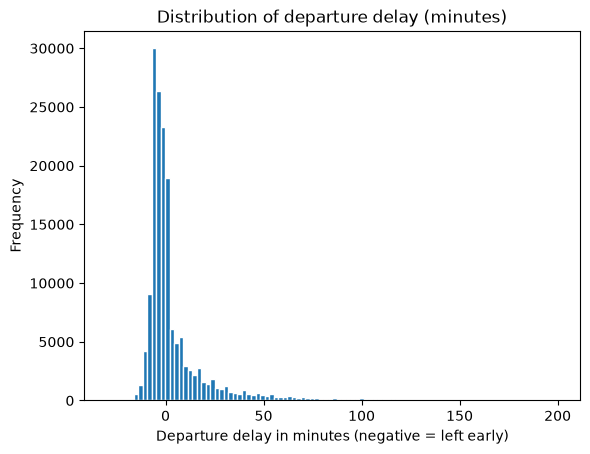

Mean:   6.1
Median: -2.0
Max:    1553.0


In [21]:
# Problem 5: the delay distribution is lopsided - a few very late flights pull the average up
df['dep_delay'].plot(kind='hist', bins=100, edgecolor='white', range=(-30, 200))
plt.title('Distribution of departure delay (minutes)')
plt.xlabel('Departure delay in minutes (negative = left early)')
plt.show()

print('Mean:  ', round(df['dep_delay'].mean(), 1))
print('Median:', df['dep_delay'].median())
print('Max:   ', df['dep_delay'].max())

We found five problems:
1. **An impossible dew point** (3,282°F) in 6 rows.
2. **Wind gust is not a real measurement.** It is always exactly 1.15 × wind speed.
3. **Air pressure is missing for 17% of flights.**
4. **"hour" is when the flight actually left, not when it was scheduled.** A 7pm flight delayed three hours shows as 10pm. Used as it is, this makes late flights look like they were scheduled late: flights that left between 1am and 4am averaged 105 minutes late.
5. **Delays are lopsided.** The typical flight leaves 2 minutes early, but a few flights are many hours late, which pulls the average up to 6 minutes.

### Cleaning decisions

In [22]:
# Cleaning step 1: set the impossible dew point to missing
corr_before = df['dewp'].corr(df['dep_delay'])
df.loc[df['dewp'] > 100, 'dewp'] = np.nan
corr_after = df['dewp'].corr(df['dep_delay'])
print('Correlation of dew point with delay - before:', round(corr_before, 3), ' after:', round(corr_after, 3))

Correlation of dew point with delay - before: -0.014  after: -0.027


In [23]:
# Cleaning step 2: drop wind_gust (copy of wind_speed) and pressure (17% missing)
df = df.drop(columns=['wind_gust', 'pressure'])

In [24]:
# Cleaning step 3: rebuild the SCHEDULED departure hour
# dep_time is written as hhmm (e.g. 1930 = 19:30). Convert to minutes after midnight,
# subtract the delay, and convert back to an hour
dep_minutes = (df['dep_time'] // 100) * 60 + (df['dep_time'] % 100)
sched_minutes = (dep_minutes - df['dep_delay']) % (24 * 60)
df['sched_hour'] = sched_minutes // 60

# Check: flights that left at 1-4am were mostly scheduled in the evening
df[df['hour'].isin([1, 2, 3, 4])]['sched_hour'].value_counts().head()

sched_hour
23.0    99
0.0     65
22.0    21
1.0     14
19.0     4
Name: count, dtype: int64

In [25]:
# Cleaning step 4: cancelled flights have no delay to measure - keep them out of the delay analysis
print('Cancelled flights:', df['dep_time'].isnull().sum())

# Cleaning step 5: flights without weather can't be used in the weather analysis
# Analysis set = flights that departed AND have weather
df_clean = df[df['dep_time'].notnull() & df['Key_Weather'].notnull()].copy()
print('Flights in analysis set:', len(df_clean))

Cancelled flights: 857


Flights in analysis set: 160280


In [26]:
# Cleaning step 6: add a yes/no column: was the flight more than 15 minutes late?
# 15 minutes is the official airline industry definition of "delayed"
df_clean['delayed'] = (df_clean['dep_delay'] > 15).astype(int)

In [27]:
# Cleaning step 7: keep extreme delays - they are real events, not errors
# How much would removing the worst 1% change the average?
cutoff = df_clean['dep_delay'].quantile(0.99)
print('99th percentile delay:', cutoff, 'minutes')
print('Average delay with all flights:     ', round(df_clean['dep_delay'].mean(), 2))
print('Average delay without the worst 1%: ', round(df_clean[df_clean['dep_delay'] <= cutoff]['dep_delay'].mean(), 2))

99th percentile delay: 127.0 minutes
Average delay with all flights:      6.13
Average delay without the worst 1%:  4.16


In [28]:
# Cleaning log - every decision in one table
cleaning_log = [
    {'Step': 'Skipped first row of weather.csv', 'Why': 'Row of column numbers above the real header', 'Rows affected': 1},
    {'Step': 'Dropped 9 empty columns in Flight.csv', 'Why': 'Left over from Excel, no data', 'Rows affected': 'all'},
    {'Step': 'Dropped weather date column', 'Why': 'Repeats year, month, day, hour', 'Rows affected': 'all'},
    {'Step': 'Dew point > 100 set to missing', 'Why': 'Physically impossible value (3,282 F)', 'Rows affected': 6},
    {'Step': 'Dropped wind_gust', 'Why': 'Always 1.15 x wind_speed, not a real measurement', 'Rows affected': 'all'},
    {'Step': 'Dropped pressure', 'Why': '17% missing', 'Rows affected': 'all'},
    {'Step': 'Added sched_hour', 'Why': 'hour is actual departure hour, which already contains the delay', 'Rows affected': 'all'},
    {'Step': 'Removed cancelled flights', 'Why': 'No delay to measure', 'Rows affected': 857},
    {'Step': 'Removed flights without weather', 'Why': 'Needed for weather analysis', 'Rows affected': 912},
    {'Step': 'Added delayed column (> 15 min)', 'Why': 'Industry definition of a delay', 'Rows affected': 'all'},
    {'Step': 'Kept extreme delays', 'Why': 'Real events that matter to passengers', 'Rows affected': 0},
]
pd.DataFrame(cleaning_log)

,Step,Why,Rows affected
0,Skipped first row of weather.csv,Row of column numbers above the real header,1
1,Dropped 9 empty columns in Flight.csv,"Left over from Excel, no data",all
2,Dropped weather date column,"Repeats year, month, day, hour",all
3,Dew point > 100 set to missing,"Physically impossible value (3,282 F)",6
4,Dropped wind_gust,"Always 1.15 x wind_speed, not a real measurement",all
5,Dropped pressure,17% missing,all
6,Added sched_hour,"hour is actual departure hour, which already c...",all
7,Removed cancelled flights,No delay to measure,857
8,Removed flights without weather,Needed for weather analysis,912
9,Added delayed column (> 15 min),Industry definition of a delay,all


**What difference the cleaning made:**
- **Fixing the dew point** doubled its correlation with delay (−0.014 to −0.027). One bad value had been hiding the relationship.
- **Rebuilding the scheduled hour** showed that the "1am–4am flights" were mostly scheduled at 11pm or midnight. They were late evening flights, not night flights.
- **We kept the extreme delays.** Removing the worst 1% would cut the average delay from 6.1 to 4.2 minutes and make performance look better than it is.

We measure risk mainly as the **share of flights more than 15 minutes late**, which is the airline industry's standard definition of a delay.

## 4. Baseline: the simplest possible answer
Before building anything: how good is the simplest possible answer?

In [29]:
# The simplest possible answer: "every flight is delayed by the average amount"
avg_delay = df_clean['dep_delay'].mean()
print('Average delay:', round(avg_delay, 1), 'minutes')

# How wrong is that guess on average? (mean absolute error)
baseline_error = (df_clean['dep_delay'] - avg_delay).abs().mean()
print('Baseline error (MAE):', round(baseline_error, 1), 'minutes')

Average delay: 6.1 minutes
Baseline error (MAE): 14.3 minutes


In [30]:
# For the yes/no question: "is this flight going to be delayed?"
pct_delayed = df_clean['delayed'].mean()
print('Share of flights delayed more than 15 minutes:', round(pct_delayed * 100, 1), '%')
print('Guessing "on time" for every flight is right', round((1 - pct_delayed) * 100, 1), '% of the time')
print('...but it never catches a single delay')

Share of flights delayed more than 15 minutes: 14.4 %
Guessing "on time" for every flight is right 85.6 % of the time
...but it never catches a single delay


- **"Every flight is delayed by the average amount (6 minutes)"** is off by **14.3 minutes** on average.
- **"Every flight will be on time"** is right **85.6%** of the time, but it never catches a single delay.

Any model we build has to beat these numbers.

## 5. What drives delay?
Each bar shows the share of flights delayed. The black lines are 95% confidence intervals, and the red line is the average.

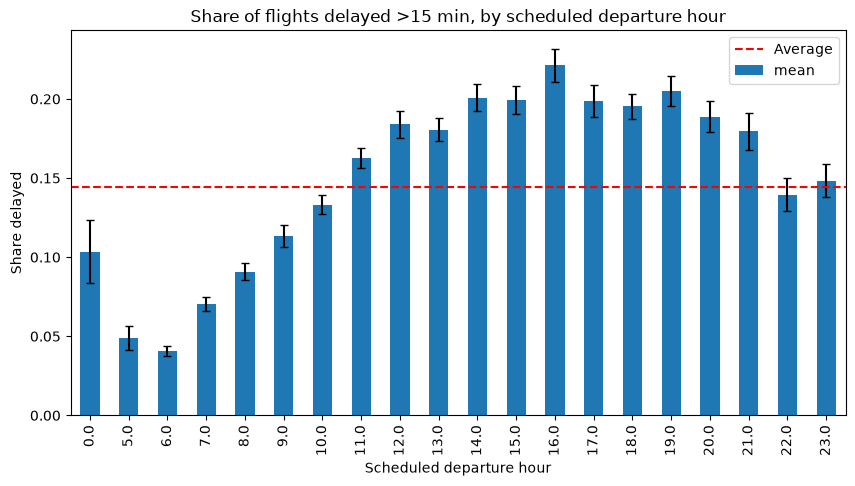

In [31]:
# Chart 1: share of flights delayed, by scheduled hour
hour_stats = df_clean.groupby('sched_hour')['delayed'].agg(['mean', 'sem', 'size'])
hour_stats = hour_stats[hour_stats['size'] > 200]      # drop hours with very few flights

hour_stats['mean'].plot(kind='bar', yerr=1.96 * hour_stats['sem'], capsize=3, figsize=(10, 5))
plt.axhline(pct_delayed, color='red', linestyle='--', label='Average')
plt.title('Share of flights delayed >15 min, by scheduled departure hour')
plt.xlabel('Scheduled departure hour')
plt.ylabel('Share delayed')
plt.legend()
plt.show()

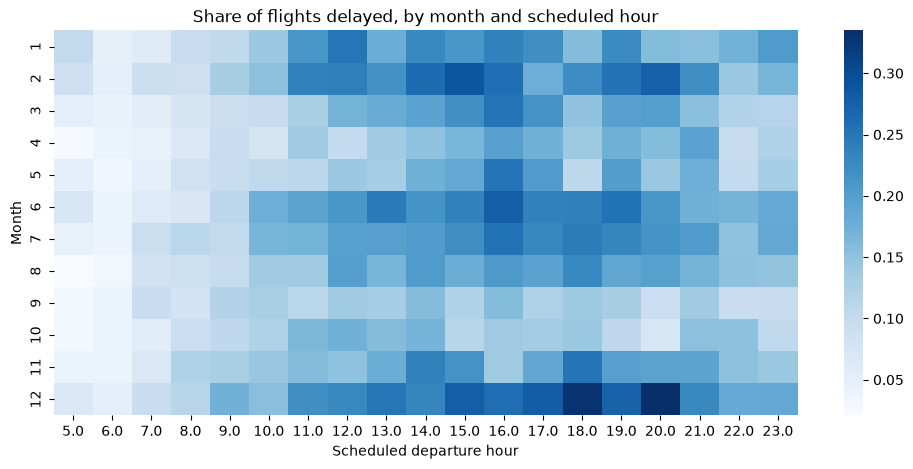

In [32]:
# Chart 2: month x hour heatmap
heat = df_clean[df_clean['sched_hour'] >= 5].groupby(['month', 'sched_hour'])['delayed'].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(heat, cmap='Blues')
plt.title('Share of flights delayed, by month and scheduled hour')
plt.xlabel('Scheduled departure hour')
plt.ylabel('Month')
plt.show()

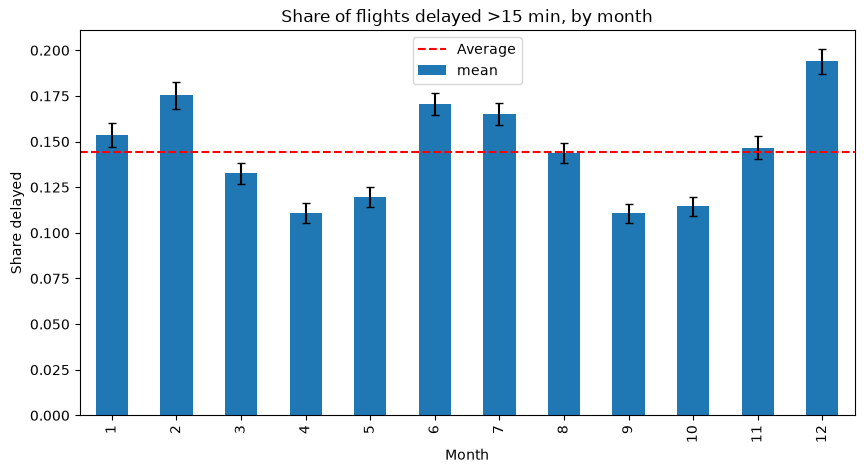

In [33]:
# Chart 3: share delayed by month
month_stats = df_clean.groupby('month')['delayed'].agg(['mean', 'sem', 'size'])

month_stats['mean'].plot(kind='bar', yerr=1.96 * month_stats['sem'], capsize=3, figsize=(10, 5))
plt.axhline(pct_delayed, color='red', linestyle='--', label='Average')
plt.title('Share of flights delayed >15 min, by month')
plt.xlabel('Month')
plt.ylabel('Share delayed')
plt.legend()
plt.show()

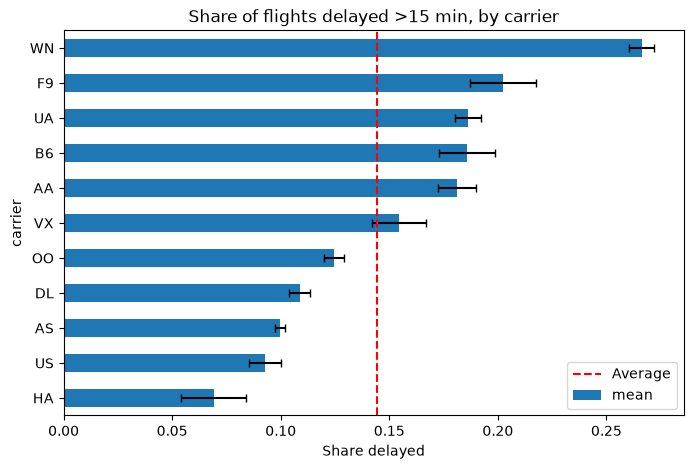

,mean,sem,size
carrier,,,
HA,0.069124,0.007705,1085
US,0.092678,0.003789,5859
AS,0.099710,0.001203,62010
DL,0.108645,0.002417,16577
OO,0.124475,0.002438,18341
VX,0.154462,0.006340,3250
AA,0.181088,0.004457,7466
B6,0.185953,0.006602,3474
UA,0.186415,0.003040,16415


In [34]:
# Chart 4: share delayed by carrier
carrier_stats = df_clean.groupby('carrier')['delayed'].agg(['mean', 'sem', 'size']).sort_values('mean')

carrier_stats['mean'].plot(kind='barh', xerr=1.96 * carrier_stats['sem'], capsize=3, figsize=(8, 5))
plt.axvline(pct_delayed, color='red', linestyle='--', label='Average')
plt.title('Share of flights delayed >15 min, by carrier')
plt.xlabel('Share delayed')
plt.legend()
plt.show()

carrier_stats

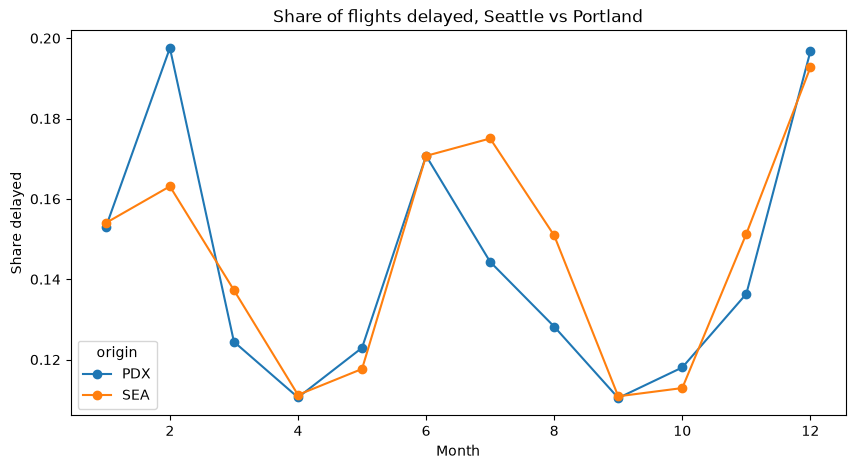

In [35]:
# Chart 5: Seattle vs Portland, by month
df_clean.groupby(['month', 'origin'])['delayed'].mean().unstack().plot(marker='o', figsize=(10, 5))
plt.title('Share of flights delayed, Seattle vs Portland')
plt.xlabel('Month')
plt.ylabel('Share delayed')
plt.show()

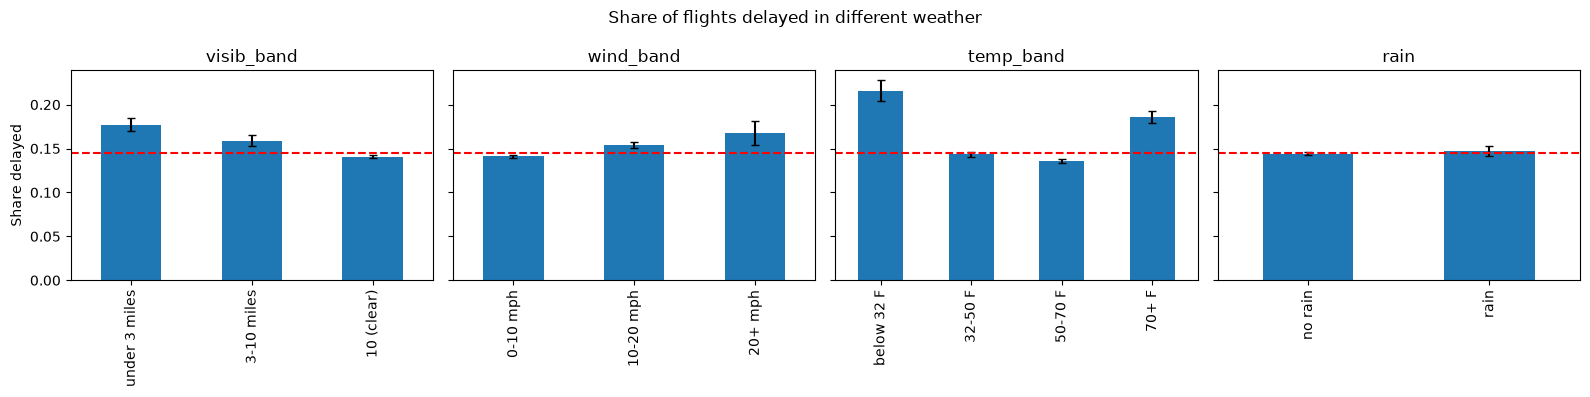

In [36]:
# Chart 6: weather - put each measurement into bands and compare the share delayed
df_clean['visib_band'] = pd.cut(df_clean['visib'], bins=[-1, 3, 9.9, 10], labels=['under 3 miles', '3-10 miles', '10 (clear)'])
df_clean['wind_band'] = pd.cut(df_clean['wind_speed'], bins=[-1, 10, 20, 50], labels=['0-10 mph', '10-20 mph', '20+ mph'])
df_clean['temp_band'] = pd.cut(df_clean['temp'], bins=[0, 32, 50, 70, 110], labels=['below 32 F', '32-50 F', '50-70 F', '70+ F'])
df_clean['rain'] = np.where(df_clean['precip'] > 0, 'rain', 'no rain')

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col in zip(axes, ['visib_band', 'wind_band', 'temp_band', 'rain']):
    s = df_clean.groupby(col, observed=True)['delayed'].agg(['mean', 'sem'])
    s['mean'].plot(kind='bar', yerr=1.96 * s['sem'], capsize=3, ax=ax)
    ax.axhline(pct_delayed, color='red', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('')
axes[0].set_ylabel('Share delayed')
plt.suptitle('Share of flights delayed in different weather')
plt.tight_layout()
plt.show()

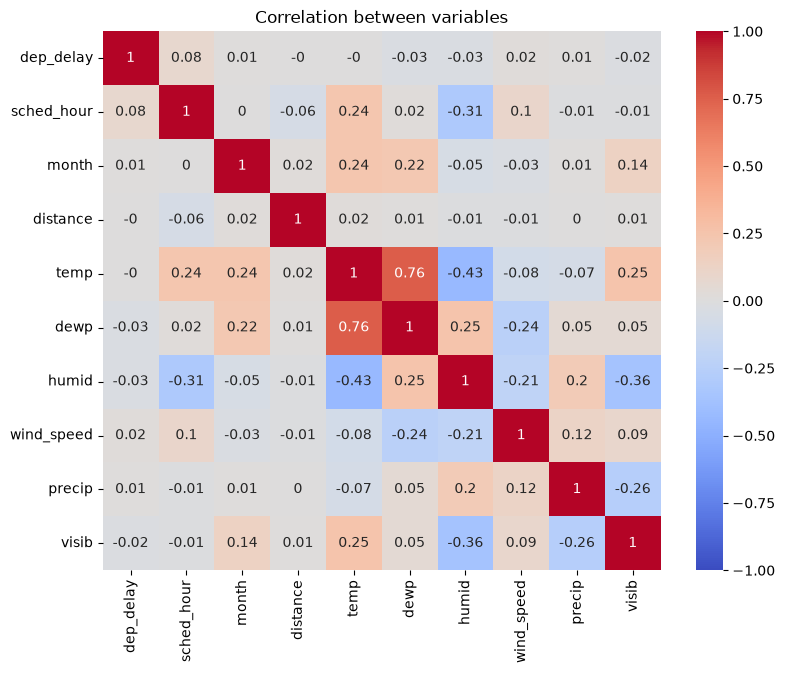

dep_delay     1.000
sched_hour    0.079
wind_speed    0.022
precip        0.007
month         0.005
temp         -0.001
distance     -0.003
visib        -0.025
dewp         -0.027
humid        -0.033
Name: dep_delay, dtype: float64

In [37]:
# Chart 7: correlation of each number with departure delay
cols = ['dep_delay', 'sched_hour', 'month', 'distance', 'temp', 'dewp', 'humid', 'wind_speed', 'precip', 'visib']

plt.figure(figsize=(9, 7))
sns.heatmap(df_clean[cols].corr().round(2), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between variables')
plt.show()

df_clean[cols].corr()['dep_delay'].sort_values(ascending=False).round(3)

**What the charts show:**
- **Risk builds through the day**, from 4% at 6am to 22% at 4pm. Morning delays carry through to the same aircraft's later flights.
- **Season matters.** December (19%), February and June–July are the worst months; April, May, September and October are the calmest.
- **Carrier gaps are large and real** (the intervals do not overlap). Southwest (27%) is delayed more than twice as often as Alaska (10%), which flies the most flights.
- **Seattle and Portland follow the same pattern**, so one plan fits both.
- **Weather matters only at the extremes.** Freezing temperatures, visibility under 3 miles and strong wind each raise risk; rain on its own makes no difference.
- **No single measurement explains delay:** every correlation with delay is below 0.1.

## 6. How sure are we?
Our numbers come from one year of flights, a sample; another year would differ slightly. The histogram shows how much the delay rate moves between random samples of 1,000 flights. With 160,000 flights, our estimates are far more precise.

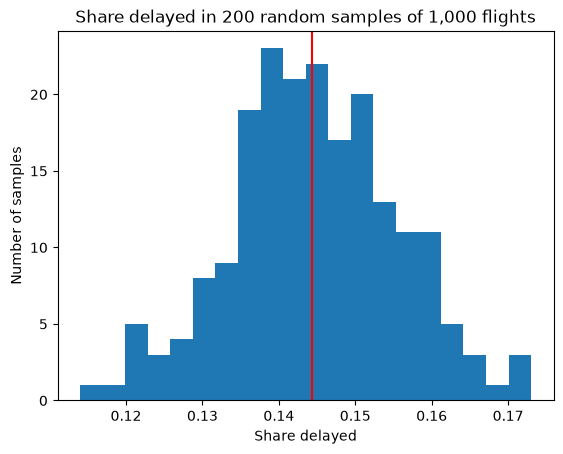

In [38]:
# How precise is our overall number? Take many random samples of 1,000 flights
sample_means = [df_clean['delayed'].sample(1000).mean() for i in range(200)]

plt.hist(sample_means, bins=20)
plt.axvline(pct_delayed, color='red')
plt.title('Share delayed in 200 random samples of 1,000 flights')
plt.xlabel('Share delayed')
plt.ylabel('Number of samples')
plt.show()

In [39]:
# 95% confidence interval for the overall share delayed (all flights)
sem = df_clean['delayed'].sem()
print('Share delayed:', round(pct_delayed * 100, 2), '%')
print('95% CI:', round((pct_delayed - 1.96 * sem) * 100, 2), '% to', round((pct_delayed + 1.96 * sem) * 100, 2), '%')

Share delayed: 14.44 %
95% CI: 14.27 % to 14.61 %


In [40]:
# Confidence intervals for the comparisons that matter to the business
df_clean['time_of_day'] = pd.cut(df_clean['sched_hour'], bins=[-1, 4, 9, 13, 16, 20, 23],
                                 labels=['night 0-4', 'morning 5-9', 'midday 10-13', 'afternoon 14-16', 'evening 17-20', 'late 21-23'])

tod = df_clean.groupby('time_of_day', observed=True)['delayed'].agg(['mean', 'sem', 'size'])
tod['LOWER'] = tod['mean'] - 1.96 * tod['sem']
tod['UPPER'] = tod['mean'] + 1.96 * tod['sem']
tod.round(3)

,mean,sem,size,LOWER,UPPER
time_of_day,,,,,
night 0-4,0.103,0.010,904,0.083,0.123
morning 5-9,0.072,0.001,51867,0.069,0.074
midday 10-13,0.163,0.002,43743,0.159,0.166
afternoon 14-16,0.206,0.003,22103,0.201,0.211
evening 17-20,0.197,0.002,28747,0.193,0.202
late 21-23,0.155,0.003,12916,0.149,0.162


In [41]:
# Same table for weather conditions
df_clean['freezing'] = np.where(df_clean['temp'] < 32, 'freezing', 'not freezing')
df_clean['low_visib'] = np.where(df_clean['visib'] < 3, 'visibility < 3 mi', 'visibility 3+ mi')

for col in ['freezing', 'low_visib', 'rain', 'origin']:
    t = df_clean.groupby(col)['delayed'].agg(['mean', 'sem', 'size'])
    t['LOWER'] = t['mean'] - 1.96 * t['sem']
    t['UPPER'] = t['mean'] + 1.96 * t['sem']
    print(t.round(3), '\n')

               mean    sem    size  LOWER  UPPER
freezing                                        
freezing      0.222  0.007    3542  0.209  0.236
not freezing  0.143  0.001  156738  0.141  0.144 

                    mean    sem    size  LOWER  UPPER
low_visib                                            
visibility 3+ mi   0.143  0.001  152319  0.141  0.145
visibility < 3 mi  0.173  0.004    7961  0.165  0.181 

          mean    sem    size  LOWER  UPPER
rain                                       
no rain  0.144  0.001  143744  0.142  0.146
rain     0.147  0.003   16536  0.142  0.153 

         mean    sem    size  LOWER  UPPER
origin                                    
PDX     0.141  0.002   52657  0.138  0.144
SEA     0.146  0.001  107623  0.144  0.148 



In [42]:
# Is the gap between evening and morning real? t-test (two groups)
evening = df_clean[df_clean['time_of_day'] == 'evening 17-20']['delayed']
morning = df_clean[df_clean['time_of_day'] == 'morning 5-9']['delayed']

diff = evening.mean() - morning.mean()
se_diff = np.sqrt(evening.sem() ** 2 + morning.sem() ** 2)
print('Evening minus morning:', round(diff * 100, 1), 'percentage points')
print('95% CI:', round((diff - 1.96 * se_diff) * 100, 1), 'to', round((diff + 1.96 * se_diff) * 100, 1))
print(stats.ttest_ind(evening, morning, equal_var=False))

Evening minus morning: 12.6 percentage points
95% CI: 12.0 to 13.1
TtestResult(statistic=np.float64(48.207036367667726), pvalue=np.float64(0.0), df=np.float64(42403.66112673491))


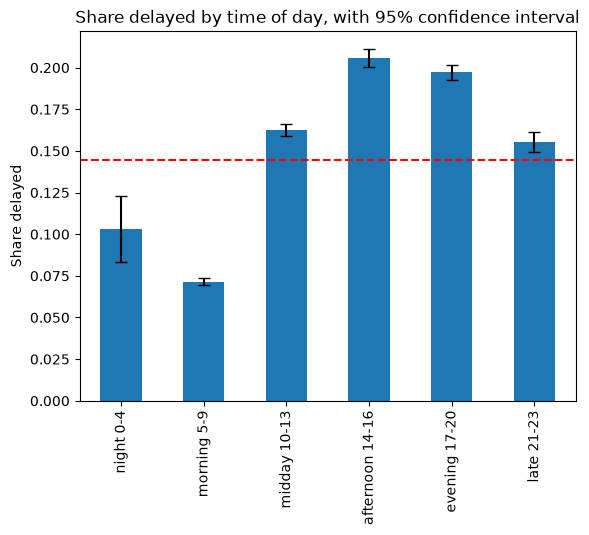

In [43]:
tod['mean'].plot(kind='bar', yerr=1.96 * tod['sem'], capsize=4)
plt.axhline(pct_delayed, color='red', linestyle='--')
plt.title('Share delayed by time of day, with 95% confidence interval')
plt.ylabel('Share delayed')
plt.xlabel('')
plt.show()

**Key estimates with 95% confidence intervals:**
- **Overall delay rate:** 14.4% (14.3%–14.6%).
- **Evening vs morning:** evening flights are delayed **12.6 points more often** (12.0–13.1). The t-test confirms this is not chance.
- **Freezing temperatures:** 22% delayed vs 14% otherwise.
- **Visibility under 3 miles:** 17% vs 14%.
- **Rain:** 14.7% vs 14.4%. The intervals overlap, so there is **no real difference**.
- **Seattle vs Portland:** 14.6% vs 14.1%. The difference is real but too small to matter.

## 7. Predicting delay with regression
**How we chose the variables:** we used only information known *before* departure: scheduled hour, month, carrier, airport and the weather at departure. Arrival delay and actual departure time were left out, because they would give away the answer.

We compared three models on 20% of flights held back for testing, and kept the simplest one that performs best.

In [44]:
# Split into training data (80%) and test data (20%) so we judge the model on flights it has not seen
train = df_clean.sample(frac=0.8, random_state=1)
test = df_clean.drop(train.index)
print('Train:', len(train), ' Test:', len(test))

# Baseline on the test set: predict the training average for every flight
baseline_mae = (test['dep_delay'] - train['dep_delay'].mean()).abs().mean()
print('Baseline error (MAE):', round(baseline_mae, 2), 'minutes')

Train: 128224  Test: 32056
Baseline error (MAE): 14.41 minutes


In [45]:
# Model 1: weather only
model_1 = smf.ols('dep_delay ~ temp + humid + wind_speed + precip + visib', data=train).fit()

# Model 2: schedule and airline only (C() = treat as categories)
model_2 = smf.ols('dep_delay ~ C(sched_hour) + C(month) + C(carrier) + origin', data=train).fit()

# Model 3: both together
model_3 = smf.ols('dep_delay ~ C(sched_hour) + C(month) + C(carrier) + origin + temp + humid + wind_speed + precip + visib',
                  data=train).fit()

# Compare on the test set
results = []
for name, m in [('1. Weather only', model_1), ('2. Schedule + airline', model_2), ('3. Both', model_3)]:
    pred = m.predict(test)
    ok = pred.notnull()
    mae = (test['dep_delay'][ok] - pred[ok]).abs().mean()
    results.append({'Model': name, 'R-squared (train)': round(m.rsquared, 3), 'Test MAE (minutes)': round(mae, 2)})
results.append({'Model': 'Baseline (average)', 'R-squared (train)': 0, 'Test MAE (minutes)': round(baseline_mae, 2)})
pd.DataFrame(results)

,Model,R-squared (train),Test MAE (minutes)
0,1. Weather only,0.003,14.38
1,2. Schedule + airline,0.038,13.65
2,3. Both,0.040,13.67
3,Baseline (average),0.000,14.41


**How well they perform:**
- **Weather alone** barely beats the baseline (14.38 vs 14.41 minutes).
- **Schedule and airline** (model 2) cut the error to 13.65 minutes.
- **Adding weather** (model 3) does not help, so **model 2 is our chosen model.**
- **Even model 2 explains only 4% of the variation in delay minutes** (R² = 0.04), and it is about 5% better than the baseline.

In [46]:
# Model 2 is our chosen model: adding weather (model 3) does not improve the test error
# Full output: coefficients, 95% confidence intervals [0.025, 0.975] and p-values
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              dep_delay   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     121.0
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:25:25   Log-Likelihood:            -6.1085e+05
No. Observations:              128224   AIC:                         1.222e+06
Df Residuals:                  128181   BIC:                         1.222e+06
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                10.57

In [47]:
# Weather effects from model 3 (extra minutes of delay per unit), with 95% confidence intervals
# They are statistically real but tiny - which is why they don't improve predictions
weather_effects = model_3.conf_int().loc[['temp', 'humid', 'wind_speed', 'precip', 'visib']]
weather_effects.columns = ['LOWER', 'UPPER']
weather_effects['coef'] = model_3.params[['temp', 'humid', 'wind_speed', 'precip', 'visib']]
weather_effects.round(2)

,LOWER,UPPER,coef
temp,0.05,0.10,0.08
humid,-0.10,-0.07,-0.08
wind_speed,0.02,0.09,0.05
precip,-0.61,19.71,9.55
visib,-0.43,-0.27,-0.35


**What the model says, holding everything else equal:**
- **A 4pm departure** runs about 11 minutes later than a 6am one.
- **Alaska** averages about 9 fewer minutes of delay than American.
- **December** adds about 3 minutes.
- **Weather effects are real but tiny.** For example, each mile of lost visibility adds about 0.35 minutes.

In [48]:
# Where does the model fail? Compare error for different sizes of delay
test = test.copy()
test['predicted'] = model_2.predict(test)
test['error'] = (test['dep_delay'] - test['predicted']).abs()
test['delay_group'] = pd.cut(test['dep_delay'], bins=[-100, 0, 15, 60, 180, 2000],
                             labels=['early/on time', '1-15 min', '16-60 min', '61-180 min', '180+ min'])

fails = test.groupby('delay_group', observed=True).agg(flights=('error', 'size'),
                                                       avg_actual=('dep_delay', 'mean'),
                                                       avg_predicted=('predicted', 'mean'),
                                                       avg_error=('error', 'mean'))
fails.round(1)

,flights,avg_actual,avg_predicted,avg_error
delay_group,,,,
early/on time,20699,-4.3,4.9,9.4
1-15 min,6646,5.9,7.5,5.4
16-60 min,3483,31.0,9.6,21.4
61-180 min,1082,95.5,9.0,86.5
180+ min,146,276.7,8.8,267.9


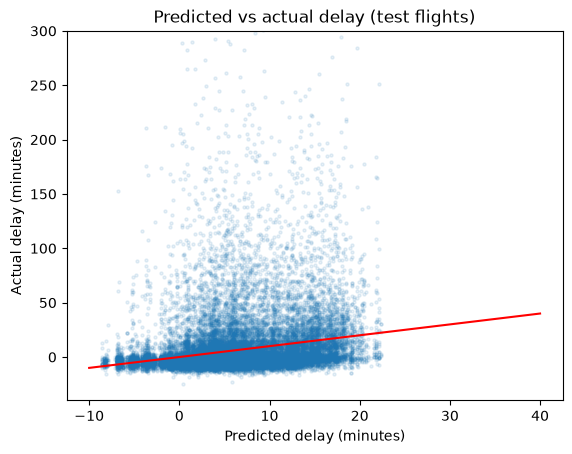

In [49]:
plt.scatter(test['predicted'], test['dep_delay'], alpha=0.1, s=5)
plt.plot([-10, 40], [-10, 40], color='red')
plt.ylim(-40, 300)
plt.title('Predicted vs actual delay (test flights)')
plt.xlabel('Predicted delay (minutes)')
plt.ylabel('Actual delay (minutes)')
plt.show()

**Where the model fails:** it cannot foresee long delays.
- It predicts between about 5 and 10 minutes for almost every flight.
- For flights that were 1–3 hours late, it is off by 86 minutes on average.
- These delays come from causes missing from our data, such as mechanical faults, crews and air-traffic holds.

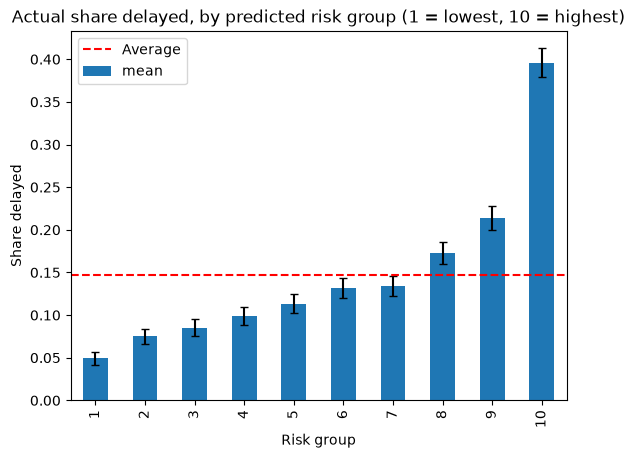

,mean,sem,size
risk_group,,,
1,0.049,0.004,3207
2,0.075,0.005,3208
3,0.085,0.005,3203
4,0.099,0.005,3206
5,0.114,0.006,3214
6,0.132,0.006,3210
7,0.134,0.006,3195
8,0.173,0.007,3204
9,0.214,0.007,3220


In [50]:
# Even if minutes are hard to predict, can the model RANK flights by risk?
# Split test flights into 10 equal groups by predicted delay, and check the real share delayed
test['risk_group'] = pd.qcut(test['predicted'], 10, labels=range(1, 11))
risk = test.groupby('risk_group', observed=True)['delayed'].agg(['mean', 'sem', 'size'])

risk['mean'].plot(kind='bar', yerr=1.96 * risk['sem'], capsize=3)
plt.axhline(test['delayed'].mean(), color='red', linestyle='--', label='Average')
plt.title('Actual share delayed, by predicted risk group (1 = lowest, 10 = highest)')
plt.xlabel('Risk group')
plt.ylabel('Share delayed')
plt.legend()
plt.show()

risk.round(3)

**But it ranks flights by risk well.** When we sort the test flights into ten groups by predicted delay:
- **The highest-risk group was actually delayed 40% of the time.**
- **The lowest-risk group was delayed only 5% of the time.**

This makes the model useful for flagging which flights to watch.

## 8. Recommendation
**What to do:**
1. **Buffer the afternoon.** Put standby crews, spare gates and extra turnaround time on departures scheduled **between 2pm and 8pm**, which are delayed 20% of the time, against 7% for early-morning flights.
2. **Plan ahead for December and freezing days.** Use the freeze forecast to set staffing a day ahead.
3. **Work with the high-delay carriers** (Southwest, Frontier, United, JetBlue, American) on afternoon turnaround times.
4. **Use the model to rank each day's flights by risk**, not to forecast exact minutes.

**How confident we are:**
- **High** that time of day, season and carrier drive delay risk. The effects are large and the intervals narrow.
- **Lower** on the size of each weather effect, because extreme-weather hours are rare.

**What this analysis does not establish:**
- **Cause and effect.** The afternoon pattern may come from delays carried over from earlier flights.
- **Long delays and cancellations.** Their causes are not in our data.
- **Other years and airports.** The data covers only 2014 at two airports, and carriers have changed since (US Airways merged into American).
- **Weather at the destination**, which we did not include.

## Division of work
*(Replace with your team's actual contributions.)*
- **[Member 1]:** Combined the two datasets (in Excel with VLOOKUP and in Python), and investigated the unmatched flights.
- **[Member 2]:** Led the data cleaning, found the actual-vs-scheduled hour problem, and wrote the cleaning log.
- **[Member 3]:** Built the visualizations and the confidence intervals.
- **[Member 4]:** Built and tested the regression models and drafted the recommendation.

**AI use statement (Hult AI policy):** *[State how AI tools were used, per your course's policy.]*